yash tawate CE48






Step 1: Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


Step 2: Load Dataset

In [ ]:
from google.colab import files

uploaded = files.upload()

df = pd.read_csv("/content/auto-mpg.csv")
df.head()

Saving auto-mpg.csv to auto-mpg (1).csv


,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


Step 3: Inspect Dataset

In [ ]:
print("First 5 Rows:")
print(df.head())

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

First 5 Rows:
    mpg  cylinders  displacement horsepower  weight  acceleration  model year  \
0  18.0          8         307.0        130    3504          12.0          70   
1  15.0          8         350.0        165    3693          11.5          70   
2  18.0          8         318.0        150    3436          11.0          70   
3  16.0          8         304.0        150    3433          12.0          70   
4  17.0          8         302.0        140    3449          10.5          70   

   origin                   car name  
0       1  chevrolet chevelle malibu  
1       1          buick skylark 320  
2       1         plymouth satellite  
3       1              amc rebel sst  
4       1                ford torino  

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylin

Step 4: Data Cleaning

In [ ]:
# Replace '?' with NaN if present
df.replace('?', np.nan, inplace=True)

# Keep only horsepower and mpg
df = df[['horsepower', 'mpg']]

# Convert horsepower to numeric
df['horsepower'] = pd.to_numeric(df['horsepower'])

# Remove missing values
df.dropna(inplace=True)

print("\nCleaned Dataset Shape:", df.shape)


Cleaned Dataset Shape: (392, 2)


Step 5: Exploratory Data Analysis (EDA)

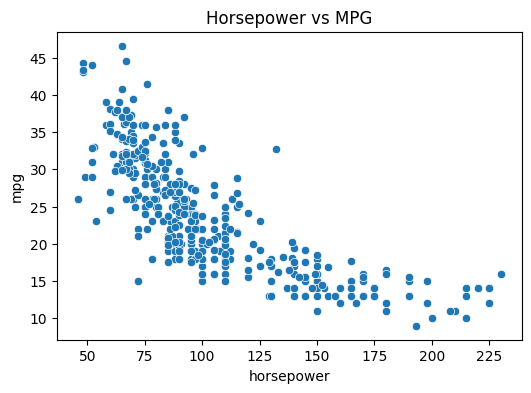


Correlation = -0.7784267838977756


In [ ]:
# Scatter Plot
plt.figure(figsize=(6,4))
sns.scatterplot(x='horsepower', y='mpg', data=df)
plt.title("Horsepower vs MPG")
plt.show()

# Correlation
correlation = df['horsepower'].corr(df['mpg'])
print("\nCorrelation =", correlation)


Step 6: Prepare Data for OLS

In [ ]:
X = df['horsepower'].values
Y = df['mpg'].values

# Add Bias Term
X_bias = np.column_stack((np.ones(len(X)), X))

Step 7: Compute OLS Weights

In [ ]:
W = np.linalg.inv(X_bias.T @ X_bias) @ (X_bias.T @ Y)

print("\nOLS Coefficients:")
print("Intercept (w0):", W[0])
print("Slope (w1):", W[1])


OLS Coefficients:
Intercept (w0): 39.93586102117056
Slope (w1): -0.1578447333536543


Step 8: Predict Values

In [ ]:
Y_pred = X_bias @ W

Step 9: Residuals

In [ ]:
residuals = Y - Y_pred

Step 10: Evaluation Metrics

In [ ]:
SSE = np.sum(residuals**2)
MSE = np.mean(residuals**2)

SST = np.sum((Y - np.mean(Y))**2)
R2 = 1 - (SSE / SST)

print("\nEvaluation Metrics")
print("SSE =", SSE)
print("MSE =", MSE)
print("R² =", R2)


Evaluation Metrics
SSE = 9385.915871932419
MSE = 23.943662938603108
R² = 0.6059482578894348


Step 11: Regression Line

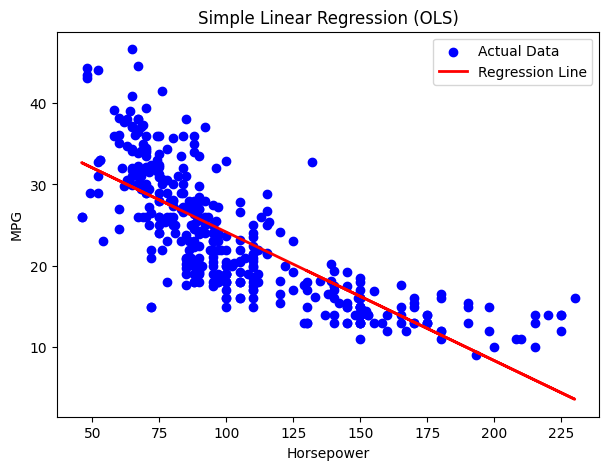

In [ ]:
plt.figure(figsize=(7,5))
plt.scatter(X, Y, color='blue', label='Actual Data')
plt.plot(X, Y_pred, color='red', linewidth=2, label='Regression Line')
plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("Simple Linear Regression (OLS)")
plt.legend()
plt.show()

Step 12: Residual Plot

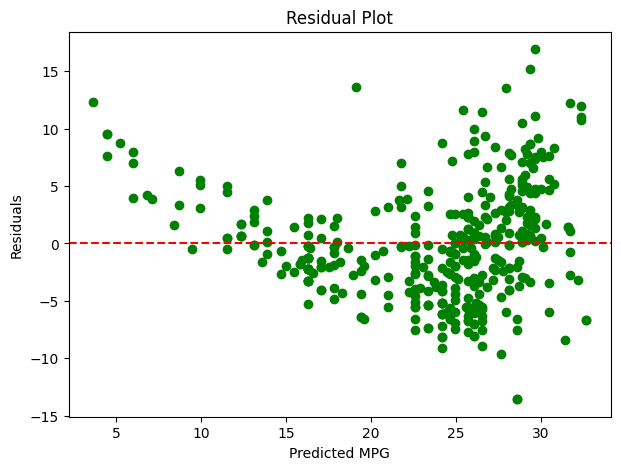

In [ ]:
plt.figure(figsize=(7,5))
plt.scatter(Y_pred, residuals, color='green')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted MPG")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

Step 13: Interpretation

In [ ]:
print("\nInterpretation:")
print("- Horsepower and MPG have a negative correlation.")
print("- As horsepower increases, fuel efficiency (MPG) decreases.")
print("- R² indicates how well the regression model explains the data.")


Interpretation:
- Horsepower and MPG have a negative correlation.
- As horsepower increases, fuel efficiency (MPG) decreases.
- R² indicates how well the regression model explains the data.
